# *****Difficulty Recommender Model*****

**Task** : Multiclass classification (Easy=0 / Normal=1 / Hard=2)  
**Input** : 8 fitur agregat riwayat sesi pemain  
**Output** : `Difficulty_Recommender.pkl`

**Strategi seleksi:** RFC dan HistGBR dibandingkan secara *head-to-head*.  
Model terbaik disimpan berdasarkan:  
1. *Validation F1 Score*  
2. Kualitas kalibrasi probabilitas  
3. *Overfitting gap* (*post-tuning learning curve*)

In [1]:
import numpy as np
import pandas as pd
import json, pickle, warnings
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import (
    RandomForestClassifier,
    HistGradientBoostingClassifier,
)
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV,
    learning_curve,
    validation_curve,
    cross_val_score,
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance
from scipy.stats import randint, uniform, loguniform

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams.update({'figure.dpi': 100, 'font.family': 'DejaVu Sans'})

# Constants (matches Sudoku.py)
FEATURES    = ['tpc', 'er', 'hr', 'cr', 'nmr', 'gur', 'avg_moves', 'avg_score']
CLASS_NAMES = ['Easy', 'Normal', 'Hard']
DATA_FILE   = 'player_data.json'

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f'Features : {FEATURES}')
print(f'Classes  : {dict(enumerate(CLASS_NAMES))}')

Features : ['tpc', 'er', 'hr', 'cr', 'nmr', 'gur', 'avg_moves', 'avg_score']
Classes  : {0: 'Easy', 1: 'Normal', 2: 'Hard'}


## 1. ***Data Generation***

### 1a. *Synthetic Data*

Distribusi fitur menggunakan **Beta / Gamma** untuk mensimulasikan perilaku pemain nyata. **Label noise 15%** ditambahkan agar model belajar pola, bukan menghafal rule deterministik.

In [2]:
def _skill(tpc, er, hr, cr, gur):
    """Weighted skill score identical to Sudoku.py labeling logic."""
    return (
        np.clip(100 - tpc * 7.0,  0, 100) * 0.32 +
        np.clip(100 - er  * 220., 0, 100) * 0.28 +
        np.clip(cr * 100,          0, 100) * 0.22 +
        np.clip(100 - hr  * 140., 0, 100) * 0.10 +
        np.clip(100 - gur * 110., 0, 100) * 0.08
    )


def generate_synthetic(n=5000, noise=0.15, seed=42):
    rng = np.random.default_rng(seed)

    tpc       = rng.gamma(shape=2.5, scale=4.0, size=n).clip(0.5, 45.0)
    er        = rng.beta(a=1.5, b=6.0,  size=n).clip(0.0, 0.80)
    hr        = rng.beta(a=1.2, b=7.0,  size=n).clip(0.0, 0.75)
    cr        = rng.beta(a=3.0, b=1.5,  size=n).clip(0.0, 1.00)
    nmr       = rng.beta(a=2.0, b=3.0,  size=n).clip(0.0, 1.00)
    gur       = rng.beta(a=1.5, b=4.0,  size=n).clip(0.0, 1.00)
    avg_moves = rng.gamma(shape=3.0, scale=12., size=n).clip(4.0, 81.0)

    skill     = _skill(tpc, er, hr, cr, gur)
    avg_score = np.clip(skill * 12.0 + rng.normal(0, 100, n), 0, 2000)

    labels = np.where(skill >= 72, 2, np.where(skill >= 42, 1, 0))
    mask   = rng.random(n) < noise
    shift  = rng.choice([-1, 1], size=n)
    labels = np.clip(labels + shift * mask, 0, 2).astype(int)

    X = np.column_stack([tpc, er, hr, cr, nmr, gur, avg_moves, avg_score])
    return X, labels


X_syn, y_syn = generate_synthetic(n=5000, noise=0.15)
print(f'Synthetic : {X_syn.shape}')
print(f'Balance   : {dict(zip(CLASS_NAMES, np.bincount(y_syn)))}')

Synthetic : (5000, 8)
Balance   : {'Easy': np.int64(919), 'Normal': np.int64(3269), 'Hard': np.int64(812)}


### 1b. Real Data (opsional)
Jika `player_data.json` tersedia, sesi aktual diambil sebagai *prefix-history* → *next-difficulty*. Data *real* di-**overweight 3×** agar model memprioritaskan pola pemain asli.

In [3]:
def load_real_data(json_path=DATA_FILE):
    if not Path(json_path).exists():
        print(f'{json_path} not found, synthetic only.')
        return np.empty((0, 8)), np.array([], dtype=int)

    with open(json_path) as f:
        data = json.load(f)

    def diff2int(d):
        return {'Easy': 0, 'Normal': 1, 'Hard': 2}.get(d, 1)

    def agg(sessions):
        n   = len(sessions)
        mv  = lambda s: max(s.get('moves', 1), 1)
        tpc = sum(s.get('total_time', 0) / mv(s) for s in sessions) / n
        er  = sum(s.get('errors', 0)     / mv(s) for s in sessions) / n
        hr  = sum(s.get('hints_used', 0) / mv(s) for s in sessions) / n
        cr  = sum(1 for s in sessions if s.get('completed', False)) / n
        te  = sum(s.get('errors', 0) for s in sessions) or 1
        nmr = sum(s.get('near_miss', 0) for s in sessions) / te
        gur = sum(s.get('guessing', 0)  for s in sessions) / te
        am  = sum(s.get('moves', 0)     for s in sessions) / n
        sc  = sum(float(s.get('score', 0) or 0) for s in sessions) / n
        return [tpc, er, hr, cr, nmr, gur, am, sc]

    X_r, y_r = [], []
    for pdata in data.get('players', {}).values():
        sess = sorted(pdata.get('sessions', []),
                      key=lambda s: s.get('timestamp', 0))
        if len(sess) < 2:
            continue
        for i in range(1, len(sess)):
            X_r.append(agg(sess[:i]))
            y_r.append(diff2int(sess[i].get('difficulty', 'Normal')))

    if not X_r:
        print('No usable sessions in JSON.')
        return np.empty((0, 8)), np.array([], dtype=int)

    X_r = np.array(X_r, dtype=float)
    y_r = np.array(y_r, dtype=int)
    print(f'Real data : {X_r.shape}')
    print(f'Balance   : {dict(zip(CLASS_NAMES, np.bincount(y_r)))}')
    return X_r, y_r

X_real, y_real = load_real_data()

player_data.json not found, synthetic only.


In [4]:
if X_real.shape[0] > 0:
    X_all = np.vstack([X_syn, np.tile(X_real, (3, 1))])
    y_all = np.concatenate([y_syn, np.tile(y_real, 3)])
    print(f'Combined  : {X_all.shape} '
          f'({X_syn.shape[0]} syn + {X_real.shape[0]*3} real x3)')
else:
    X_all, y_all = X_syn.copy(), y_syn.copy()
    print(f'Synthetic only: {X_all.shape}')

perm  = np.random.permutation(len(X_all))
X_all, y_all = X_all[perm], y_all[perm]

df = pd.DataFrame(X_all, columns=FEATURES)
df['label'] = y_all
df['class'] = df['label'].map(dict(enumerate(CLASS_NAMES)))

print(f'\nFinal class balance:')
print(df['class'].value_counts().to_string())

Synthetic only: (5000, 8)

Final class balance:
class
Normal    3269
Easy       919
Hard       812


## 2. ***Exploratory Data Analysis* (EDA)**

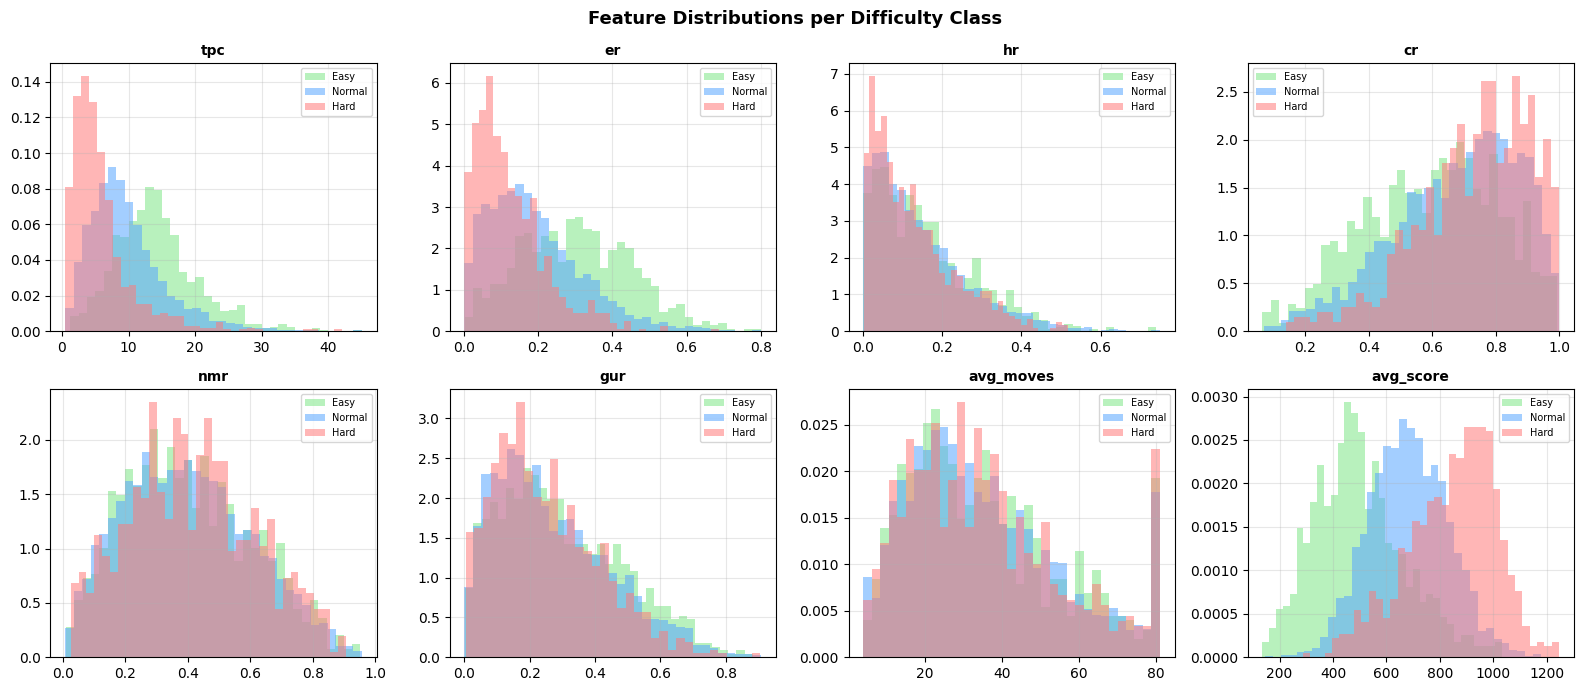

In [5]:
COLORS = {'Easy': '#7EE787', 'Normal': '#58A6FF', 'Hard': '#FF7B7B'}

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle('Feature Distributions per Difficulty Class', fontsize=13, fontweight='bold')

for ax, feat in zip(axes.flat, FEATURES):
    for cls in CLASS_NAMES:
        ax.hist(df.loc[df['class'] == cls, feat],
                bins=35, alpha=0.55, label=cls, color=COLORS[cls], density=True)
    ax.set_title(feat, fontweight='bold', fontsize=10)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

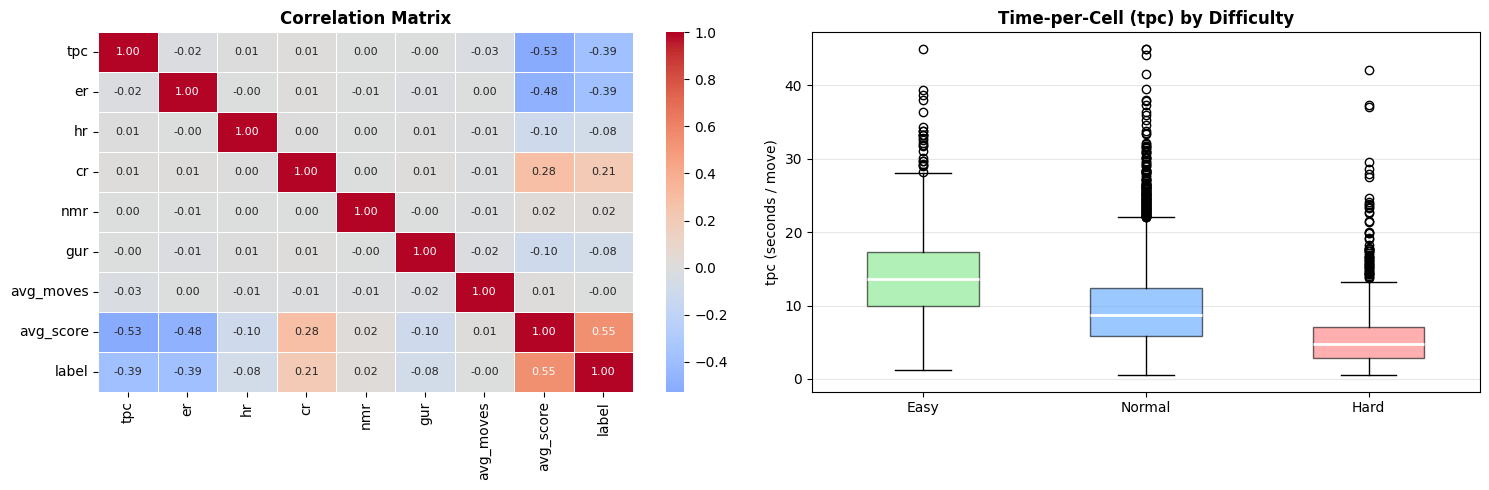

Correlation with label (difficulty):
avg_score    0.552325
tpc         -0.387754
er          -0.385588
cr           0.210320
hr          -0.083079
gur         -0.082201
nmr          0.018829
avg_moves   -0.000887


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

corr = df[FEATURES + ['label']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[0], annot_kws={'size': 8}, linewidths=0.4)
axes[0].set_title('Correlation Matrix', fontweight='bold')

for i, cls in enumerate(CLASS_NAMES):
    vals = df.loc[df['class'] == cls, 'tpc']
    axes[1].boxplot(vals, positions=[i], widths=0.5,
                    patch_artist=True,
                    boxprops=dict(facecolor=COLORS[cls], alpha=0.6),
                    medianprops=dict(color='white', linewidth=2))
axes[1].set_xticks([0, 1, 2])
axes[1].set_xticklabels(CLASS_NAMES)
axes[1].set_title('Time-per-Cell (tpc) by Difficulty', fontweight='bold')
axes[1].set_ylabel('tpc (seconds / move)')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print('Correlation with label (difficulty):')
print(corr['label'].drop('label').sort_values(key=abs, ascending=False).to_string())

## 3. ***Preprocessing***

- Split stratified **60 / 20 / 20** (train / val / test)
- `StandardScaler` fit **hanya pada train**
- Val dipakai untuk seleksi model, test **hanya** untuk evaluasi akhir


In [7]:
X_tv, X_test, y_tv, y_test = train_test_split(
    X_all, y_all, test_size=0.20, random_state=42, stratify=y_all)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.25, random_state=42, stratify=y_tv)

print(f'Train : {X_train.shape}  classes={np.bincount(y_train)}')
print(f'Val   : {X_val.shape}    classes={np.bincount(y_val)}')
print(f'Test  : {X_test.shape}   classes={np.bincount(y_test)}')

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print(f'\nScaler mean  : {scaler.mean_.round(3)}')
print(f'Scaler scale : {scaler.scale_.round(3)}')

Train : (3000, 8)  classes=[ 551 1961  488]
Val   : (1000, 8)    classes=[184 654 162]
Test  : (1000, 8)   classes=[184 654 162]

Scaler mean  : [1.00340e+01 2.01000e-01 1.43000e-01 6.64000e-01 4.03000e-01 2.72000e-01
 3.56330e+01 6.72059e+02]
Scaler scale : [6.29600e+00 1.39000e-01 1.17000e-01 2.01000e-01 2.00000e-01 1.75000e-01
 1.94570e+01 1.87267e+02]


## 4. ***Baseline Models***


In [8]:
rfc_base = RandomForestClassifier(
    n_estimators=100, random_state=42,
    class_weight='balanced_subsample', n_jobs=-1)

HistGBR_base = HistGradientBoostingClassifier(
    max_iter=100, random_state=42, class_weight='balanced')

print(f'{"Model":<30} {"CV F1-Macro":>12} {"±std":>8}')
print('-' * 54)

for tag, mdl in [('RFC (baseline)', rfc_base), ('HistGBR (baseline)', HistGBR_base)]:
    res = cross_val_score(
        mdl, X_train_sc, y_train, cv=CV,
        scoring='f1_macro', n_jobs=-1)
    print(f'{tag:<30} {res.mean():>12.4f} {res.std():>8.4f}')


Model                           CV F1-Macro     ±std
------------------------------------------------------
RFC (baseline)                       0.6920   0.0349
HistGBR (baseline)                   0.7121   0.0239


## 5. **Diagnosis *Learning & Validation Curves***

**Interpretasi gap (train − validation):**
- `gap < 0.05` → fit baik  
- `gap 0.05–0.10` → *mild variance* (*acceptable*)  
- `gap > 0.10` → *high variance* (*overfit*)  
- *Val score plateau* rendah → high bias (*underfit*)

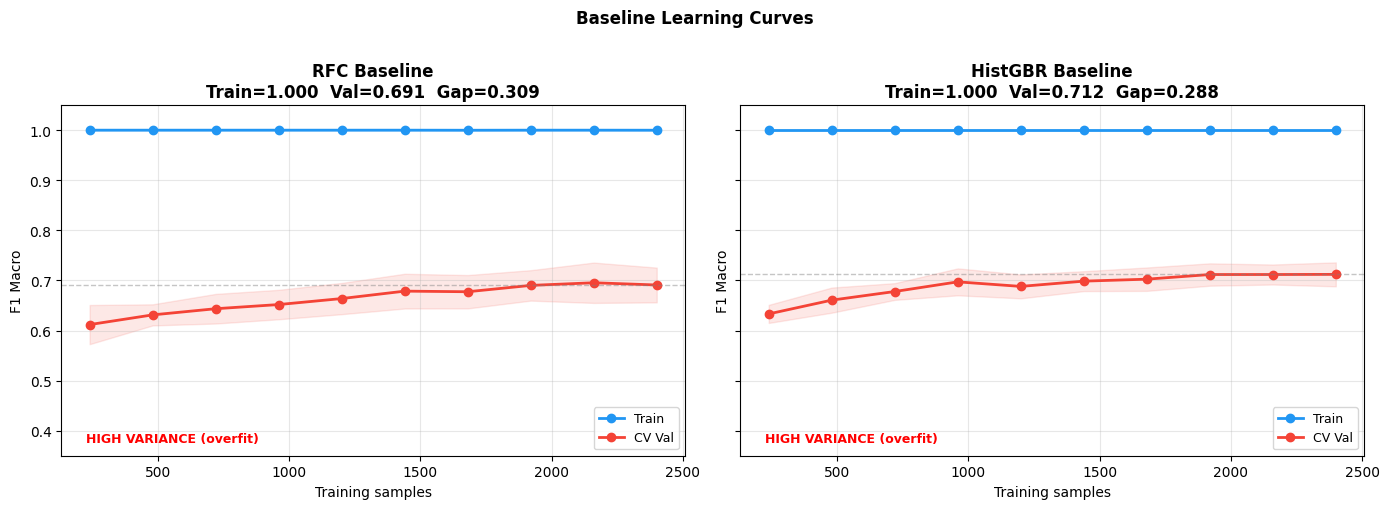

In [9]:
def plot_lc(models_tags, X, y, cv, title='Learning Curves', figsize=(14, 5)):
    fig, axes = plt.subplots(1, len(models_tags), figsize=figsize, sharey=True)
    if len(models_tags) == 1:
        axes = [axes]
    sizes = np.linspace(0.10, 1.0, 10)

    for ax, (mdl, tag) in zip(axes, models_tags):
        ts, tr, vl = learning_curve(
            mdl, X, y, train_sizes=sizes, cv=cv,
            scoring='f1_macro', n_jobs=-1,
            shuffle=True, random_state=42)
        tr_m, tr_s = tr.mean(1), tr.std(1)
        vl_m, vl_s = vl.mean(1), vl.std(1)
        gap = tr_m[-1] - vl_m[-1]

        ax.plot(ts, tr_m, 'o-', color='#2196F3', lw=2, label='Train')
        ax.fill_between(ts, tr_m-tr_s, tr_m+tr_s, alpha=0.12, color='#2196F3')
        ax.plot(ts, vl_m, 'o-', color='#F44336', lw=2, label='CV Val')
        ax.fill_between(ts, vl_m-vl_s, vl_m+vl_s, alpha=0.12, color='#F44336')
        ax.axhline(vl_m[-1], ls='--', color='gray', alpha=0.45, lw=1)

        if gap > 0.10:
            diag, col = 'HIGH VARIANCE (overfit)', 'red'
        elif gap > 0.05:
            diag, col = 'Mild variance', 'orange'
        elif vl_m[-1] < 0.60:
            diag, col = 'HIGH BIAS (underfit)', 'red'
        else:
            diag, col = 'Good fit', 'green'

        ax.text(0.04, 0.04, diag, transform=ax.transAxes,
                color=col, fontsize=9, fontweight='bold')
        ax.set_title(
            f'{tag}\nTrain={tr_m[-1]:.3f}  Val={vl_m[-1]:.3f}  Gap={gap:.3f}',
            fontweight='bold')
        ax.set_xlabel('Training samples')
        ax.set_ylabel('F1 Macro')
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)
        ax.set_ylim(0.35, 1.05)

    fig.suptitle(title, fontsize=12, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


plot_lc([(rfc_base, 'RFC Baseline'), (HistGBR_base, 'HistGBR Baseline')],
        X_train_sc, y_train, CV, title='Baseline Learning Curves')


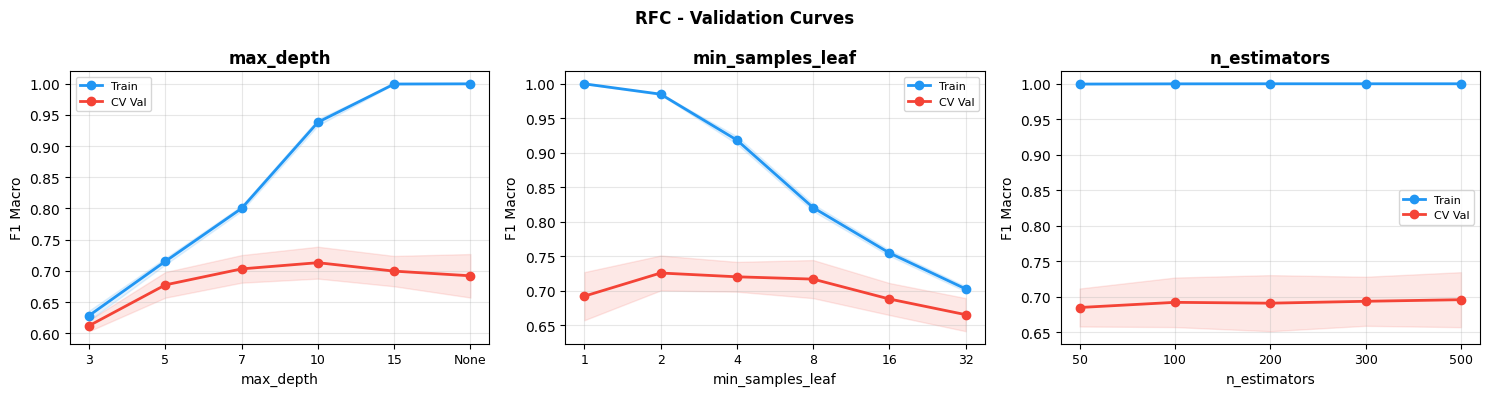

In [10]:
# Validation Curves: RFC
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('RFC - Validation Curves', fontsize=12, fontweight='bold')

rfc_vc_cfg = [
    ('max_depth',        [3, 5, 7, 10, 15, None]),
    ('min_samples_leaf', [1, 2, 4, 8, 16, 32]),
    ('n_estimators',     [50, 100, 200, 300, 500]),
]
for ax, (param, p_range) in zip(axes, rfc_vc_cfg):
    base = RandomForestClassifier(
        random_state=42, class_weight='balanced_subsample', n_jobs=-1)
    tr_s, vl_s = validation_curve(
        base, X_train_sc, y_train,
        param_name=param, param_range=p_range,
        cv=CV, scoring='f1_macro', n_jobs=-1)
    xp  = list(range(len(p_range)))
    xlb = [str(p) for p in p_range]
    ax.plot(xp, tr_s.mean(1), 'o-', c='#2196F3', lw=2, label='Train')
    ax.fill_between(xp, tr_s.mean(1)-tr_s.std(1),
                    tr_s.mean(1)+tr_s.std(1), alpha=0.12, color='#2196F3')
    ax.plot(xp, vl_s.mean(1), 'o-', c='#F44336', lw=2, label='CV Val')
    ax.fill_between(xp, vl_s.mean(1)-vl_s.std(1),
                    vl_s.mean(1)+vl_s.std(1), alpha=0.12, color='#F44336')
    ax.set_xticks(xp)
    ax.set_xticklabels(xlb, fontsize=9)
    ax.set_title(param, fontweight='bold')
    ax.set_xlabel(param)
    ax.set_ylabel('F1 Macro')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

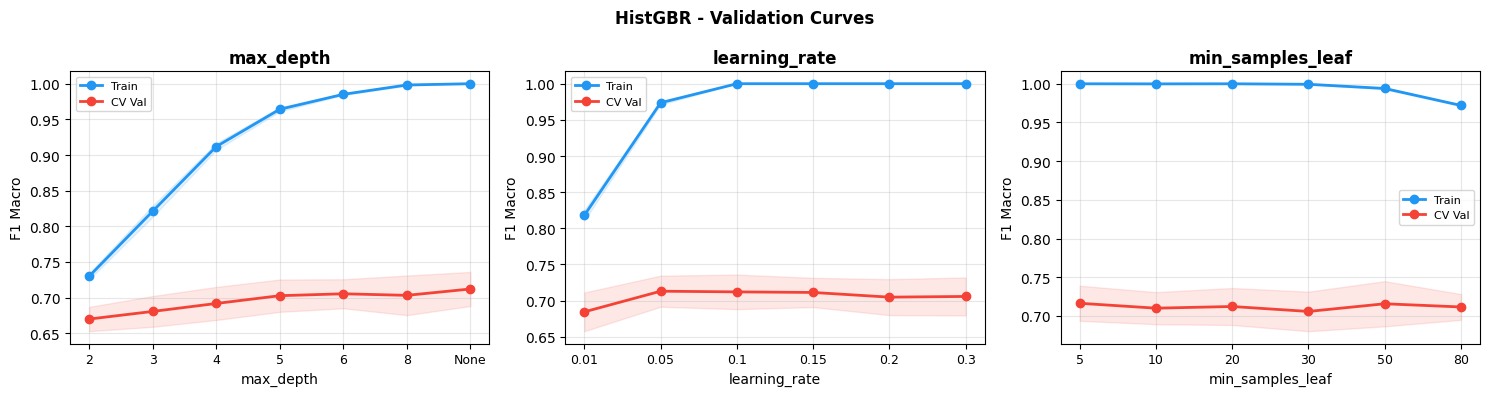

In [11]:
# Validation Curves: HistGBR
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('HistGBR - Validation Curves', fontsize=12, fontweight='bold')

HistGBR_vc_cfg = [
    ('max_depth',        [2, 3, 4, 5, 6, 8, None]),
    ('learning_rate',    [0.01, 0.05, 0.10, 0.15, 0.20, 0.30]),
    ('min_samples_leaf', [5, 10, 20, 30, 50, 80]),
]
for ax, (param, p_range) in zip(axes, HistGBR_vc_cfg):
    base = HistGradientBoostingClassifier(random_state=42, class_weight='balanced')
    tr_s, vl_s = validation_curve(
        base, X_train_sc, y_train,
        param_name=param, param_range=p_range,
        cv=CV, scoring='f1_macro', n_jobs=-1)
    xp  = list(range(len(p_range)))
    xlb = [str(p) for p in p_range]
    ax.plot(xp, tr_s.mean(1), 'o-', c='#2196F3', lw=2, label='Train')
    ax.fill_between(xp, tr_s.mean(1)-tr_s.std(1),
                    tr_s.mean(1)+tr_s.std(1), alpha=0.12, color='#2196F3')
    ax.plot(xp, vl_s.mean(1), 'o-', c='#F44336', lw=2, label='CV Val')
    ax.fill_between(xp, vl_s.mean(1)-vl_s.std(1),
                    vl_s.mean(1)+vl_s.std(1), alpha=0.12, color='#F44336')
    ax.set_xticks(xp)
    ax.set_xticklabels(xlb, fontsize=9)
    ax.set_title(param, fontweight='bold')
    ax.set_xlabel(param)
    ax.set_ylabel('F1 Macro')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. ***Hyperparameter Tuning***

**Strategi:**
- `RandomizedSearchCV` dengan `n_iter=60`, `StratifiedKFold(5)`
- Scoring: `f1_macro`, *robust* terhadap *class imbalance*
- RFC: Regularisasi utama lewat `min_samples_leaf`, `min_samples_split`, `max_samples`
- HistGBR: Regularisasi utama lewat `min_samples_leaf`, `l2_regularization`, `max_leaf_nodes`


In [12]:
# RFC Tuning
rfc_dist = {
    'n_estimators'     : randint(150, 600),
    'max_depth'        : [None, 8, 10, 12, 15, 20],
    'min_samples_leaf' : randint(2, 20),
    'min_samples_split': randint(5, 25),
    'max_features'     : ['sqrt', 'log2', 0.5, 0.7],
    'class_weight'     : ['balanced', 'balanced_subsample'],
    'max_samples'      : uniform(0.60, 0.35),
}

rfc_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, bootstrap=True, n_jobs=-1),
    param_distributions=rfc_dist,
    n_iter=60, cv=CV,
    scoring='f1_macro',
    refit=True, n_jobs=-1,
    random_state=42, verbose=0)

rfc_search.fit(X_train_sc, y_train)
rfc_best = rfc_search.best_estimator_

print('RFC Best Parameters:')
for k, v in rfc_search.best_params_.items():
    print(f'  {k:<22}: {v}')
print(f'\nCV   F1 Macro : {rfc_search.best_score_:.4f}')
print(f'Val  F1 Macro : '
      f'{f1_score(y_val, rfc_best.predict(X_val_sc), average="macro"):.4f}')

RFC Best Parameters:
  class_weight          : balanced_subsample
  max_depth             : None
  max_features          : log2
  max_samples           : 0.9276541709562733
  min_samples_leaf      : 4
  min_samples_split     : 12
  n_estimators          : 323

CV   F1 Macro : 0.7284
Val  F1 Macro : 0.7436


In [13]:
# HistGBR Tuning
HistGBR_dist = {
    'max_iter'         : randint(100, 500),
    'max_depth'        : [3, 4, 5, 6, None],
    'learning_rate'    : uniform(0.01, 0.24),
    'min_samples_leaf' : randint(10, 60),
    'l2_regularization': loguniform(0.01, 10.0),
    'max_leaf_nodes'   : [20, 31, 50, 63, 100, None],
}

HistGBR_search = RandomizedSearchCV(
    HistGradientBoostingClassifier(random_state=42, class_weight='balanced'),
    param_distributions=HistGBR_dist,
    n_iter=60, cv=CV,
    scoring='f1_macro',
    refit=True, n_jobs=-1,
    random_state=42, verbose=0)

HistGBR_search.fit(X_train_sc, y_train)
HistGBR_best = HistGBR_search.best_estimator_

print('HistGBR Best Parameters:')
for k, v in HistGBR_search.best_params_.items():
    print(f'  {k:<22}: {v}')
print(f'\nCV   F1 Macro : {HistGBR_search.best_score_:.4f}')
print(f'Val  F1 Macro : '
      f'{f1_score(y_val, HistGBR_best.predict(X_val_sc), average="macro"):.4f}')

HistGBR Best Parameters:
  l2_regularization     : 0.04335281794951567
  learning_rate         : 0.053637992129704146
  max_depth             : None
  max_iter              : 260
  max_leaf_nodes        : 63
  min_samples_leaf      : 31

CV   F1 Macro : 0.7231
Val  F1 Macro : 0.7258


## 7. ***Model Comparison & Selection***

Seleksi model menggunakan **tiga kriteria** secara berurutan:
1. ***Validation F1 Macro*** sebagai metrik utama
2. **Kalibrasi probabilitas** karena `Sudoku.py` menampilkan confidence %
3. ***Post-tuning overfitting gap*** karena model dengan gap lebih kecil lebih *robust*


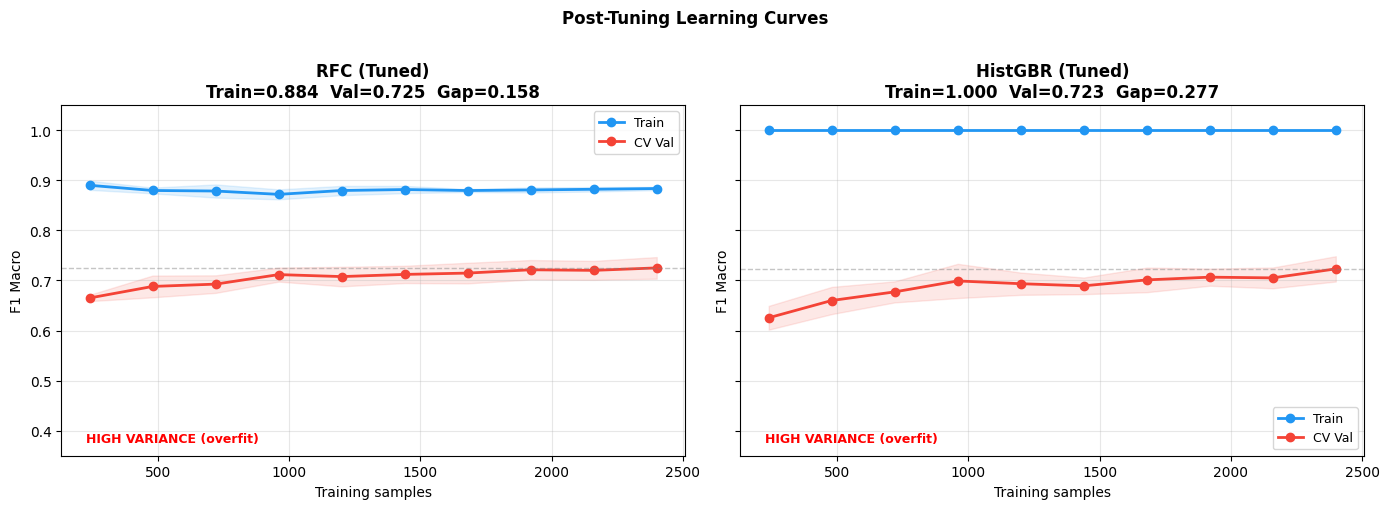

In [14]:
# Post-tuning Learning Curves
plot_lc([(rfc_best, 'RFC (Tuned)'), (HistGBR_best, 'HistGBR (Tuned)')],
        X_train_sc, y_train, CV, title='Post-Tuning Learning Curves')

In [15]:
# Metrik Perbandingan
results = {}
print(f'{"Model":<22} {"CV F1":>8} {"±":>6} {"Val F1":>8} {"Gap":>8}')
print('-' * 58)

for tag, mdl in [('RFC (tuned)', rfc_best), ('HistGBR (tuned)', HistGBR_best)]:
    cv_f1 = cross_val_score(
        mdl, X_train_sc, y_train, cv=CV,
        scoring='f1_macro', n_jobs=-1)
    yp    = mdl.predict(X_val_sc)
    vl_f1 = f1_score(y_val, yp, average='macro')
    gap   = cv_f1.mean() - vl_f1
    results[tag] = dict(cv_f1=cv_f1.mean(), cv_std=cv_f1.std(),
                        val_f1=vl_f1, gap=gap)
    print(f'{tag:<22} {cv_f1.mean():>8.4f} {cv_f1.std():>6.4f} '
          f'{vl_f1:>8.4f} {gap:>8.4f}')


Model                     CV F1      ±   Val F1      Gap
----------------------------------------------------------
RFC (tuned)              0.7284 0.0237   0.7436  -0.0152
HistGBR (tuned)          0.7231 0.0252   0.7258  -0.0027


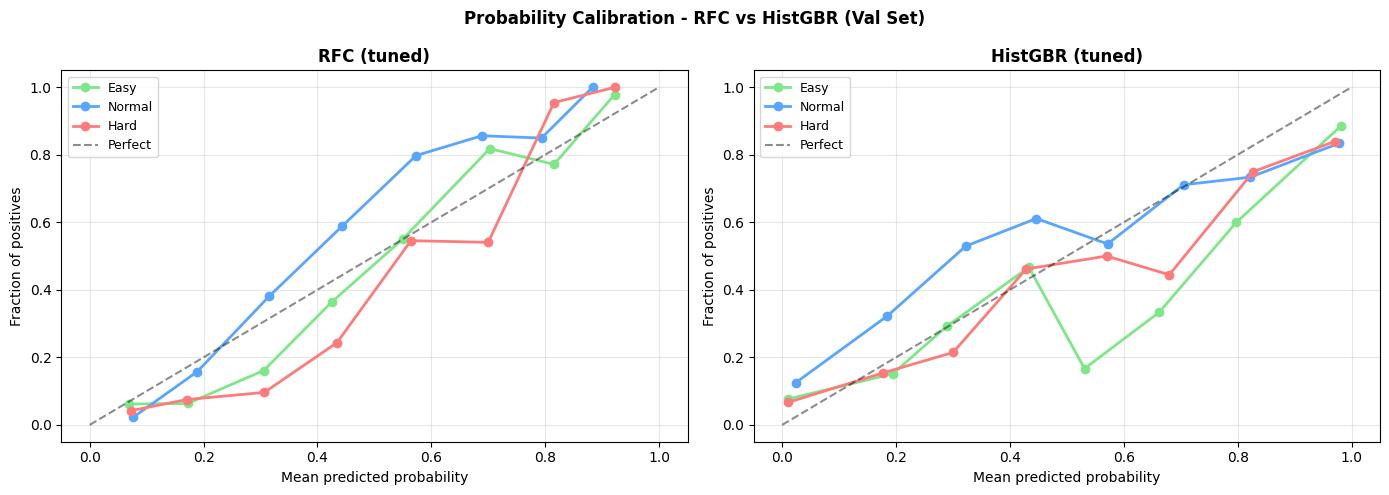

In [16]:
# Kalibrasi Probabilitas
# Kalibrasi penting: Sudoku.py menampilkan confidence % dari predict_proba.
# Model yang terkalibrasi baik = kurva mendekati diagonal sempurna.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Probability Calibration - RFC vs HistGBR (Val Set)',
             fontsize=12, fontweight='bold')

cls_colors = ['#7EE787', '#58A6FF', '#FF7B7B']
for ax, (tag, mdl) in zip(axes, [('RFC (tuned)', rfc_best), ('HistGBR (tuned)', HistGBR_best)]):
    proba = mdl.predict_proba(X_val_sc)
    for i, (cls, col) in enumerate(zip(CLASS_NAMES, cls_colors)):
        y_bin = (y_val == i).astype(int)
        pt, pp = calibration_curve(y_bin, proba[:, i], n_bins=8)
        ax.plot(pp, pt, 'o-', label=cls, color=col, lw=2)
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.45, label='Perfect')
    ax.set_title(f'{tag}', fontweight='bold')
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
# Seleksi Model Terbaik
# Kriteria 1: Validation F1 Macro (primer)
# Kriteria 2: Overfitting gap (sekunder, lebih kecil lebih baik)

val_f1_rfc = results['RFC (tuned)']['val_f1']
val_f1_HistGBR = results['HistGBR (tuned)']['val_f1']
gap_rfc    = abs(results['RFC (tuned)']['gap'])
gap_HistGBR    = abs(results['HistGBR (tuned)']['gap'])

print('Perbandingan RFC vs HistGBR:')
print(f'  RFC  Val F1={val_f1_rfc:.4f}  Gap={gap_rfc:.4f}')
print(f'  HistGBR  Val F1={val_f1_HistGBR:.4f}  Gap={gap_HistGBR:.4f}')

# Seleksi: F1 lebih tinggi wins; jika tie, gap lebih kecil wins
if abs(val_f1_HistGBR - val_f1_rfc) < 0.002:
    # Perbedaan F1 di bawah 0.2pp → gunakan gap sebagai tiebreaker
    if gap_HistGBR <= gap_rfc:
        best_name, best_model = 'HistGBR', HistGBR_best
        reason = f'F1 setara (diff={abs(val_f1_HistGBR-val_f1_rfc):.4f}), HistGBR gap lebih kecil ({gap_HistGBR:.4f} vs {gap_rfc:.4f})'
    else:
        best_name, best_model = 'RFC', rfc_best
        reason = f'F1 setara, RFC gap lebih kecil ({gap_rfc:.4f} vs {gap_HistGBR:.4f})'
elif val_f1_HistGBR > val_f1_rfc:
    best_name, best_model = 'HistGBR', HistGBR_best
    reason = f'HistGBR Val F1 lebih tinggi ({val_f1_HistGBR:.4f} > {val_f1_rfc:.4f})'
else:
    best_name, best_model = 'RFC', rfc_best
    reason = f'RFC Val F1 lebih tinggi ({val_f1_rfc:.4f} > {val_f1_HistGBR:.4f})'

print(f'\nModel terpilih : {best_name}')
print(f'Alasan         : {reason}')
print(f'Tipe           : {type(best_model).__name__}')


Perbandingan RFC vs HistGBR:
  RFC  Val F1=0.7436  Gap=0.0152
  HistGBR  Val F1=0.7258  Gap=0.0027

Model terpilih : RFC
Alasan         : RFC Val F1 lebih tinggi (0.7436 > 0.7258)
Tipe           : RandomForestClassifier


## 8. ***Final Evaluation & Overfit Check***

Test set **tidak pernah disentuh** selama tuning maupun seleksi. Evaluasi ini menunjukkan performa generalisasi sesungguhnya.

**Kriteria lolos:**
- `gap (CV − Test) < 0.05` artinya tidak *overfit*
- `F1 macro ≥ 0.70` artinya tidak *underfit*
- `F1 per kelas ≥ 0.60` artinya seimbang antar kelas



In [18]:
y_pred_test = best_model.predict(X_test_sc)
f1_test     = f1_score(y_test, y_pred_test, average='macro')

cv_f1_final = cross_val_score(
    best_model, X_train_sc, y_train, cv=CV,
    scoring='f1_macro', n_jobs=-1).mean()

gap_cv_test = cv_f1_final - f1_test

print('=' * 55)
print(f'FINAL TEST SET EVALUATION - {best_name}')
print('=' * 55)
print(f'CV  F1 Macro (train folds) : {cv_f1_final:.4f}')
print(f'Test F1 Macro (held-out)   : {f1_test:.4f}')
print(f'Gap (CV - Test)            : {gap_cv_test:.4f}')

print('\nOverfit Check :', end=' ')
if gap_cv_test < 0.05:
    print('PASS - no significant overfitting')
elif gap_cv_test < 0.10:
    print('WARN - mild overfitting (acceptable)')
else:
    print('FAIL - significant overfitting, re-tune regularization')

print('Underfit Check:', end=' ')
if f1_test >= 0.70:
    print('PASS')
else:
    print('WARN - consider a more expressive model')

print(f'\nClassification Report:\n')
print(classification_report(y_test, y_pred_test, target_names=CLASS_NAMES))

FINAL TEST SET EVALUATION - RFC
CV  F1 Macro (train folds) : 0.7284
Test F1 Macro (held-out)   : 0.7127
Gap (CV - Test)            : 0.0157

Overfit Check : PASS - no significant overfitting
Underfit Check: PASS

Classification Report:

              precision    recall  f1-score   support

        Easy       0.77      0.61      0.68       184
      Normal       0.81      0.87      0.84       654
        Hard       0.64      0.59      0.62       162

    accuracy                           0.78      1000
   macro avg       0.74      0.69      0.71      1000
weighted avg       0.77      0.78      0.77      1000



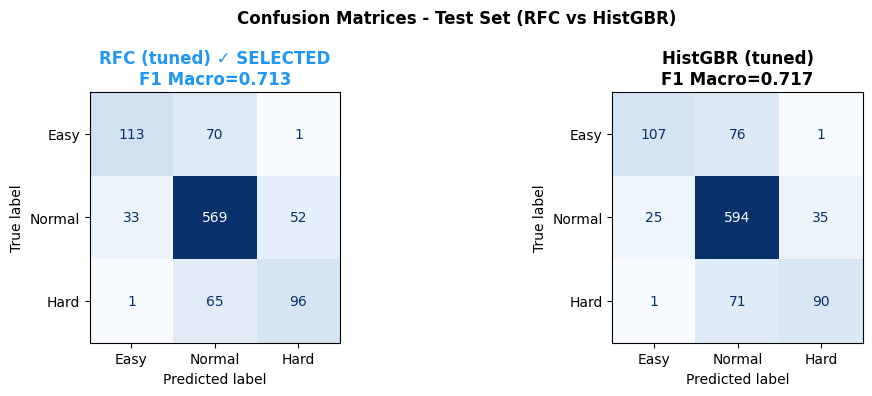

In [19]:
# Confusion Matrix: RFC vs HistGBR
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Confusion Matrices - Test Set (RFC vs HistGBR)',
             fontsize=12, fontweight='bold')

for ax, (tag, mdl) in zip(axes, [
    ('RFC (tuned)', rfc_best),
    ('HistGBR (tuned)', HistGBR_best),
]):
    yp   = mdl.predict(X_test_sc)
    f1   = f1_score(y_test, yp, average='macro')
    cm   = confusion_matrix(y_test, yp)
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    winner_tag = ' ✓ SELECTED' if tag.startswith(best_name) else ''
    ax.set_title(f'{tag}{winner_tag}\nF1 Macro={f1:.3f}',
                 fontweight='bold',
                 color='#2196F3' if winner_tag else 'black')

plt.tight_layout()
plt.show()

## 9. ***Feature Importance***

**Gini (RFC built-in)** : cepat tapi bias terhadap fitur *high-cardinality*  
**Permutation Importance** : model-*agnostic*, lebih reliable karena mengukur dampak nyata terhadap skor  
Keduanya ditampilkan untuk model yang **terpilih**.


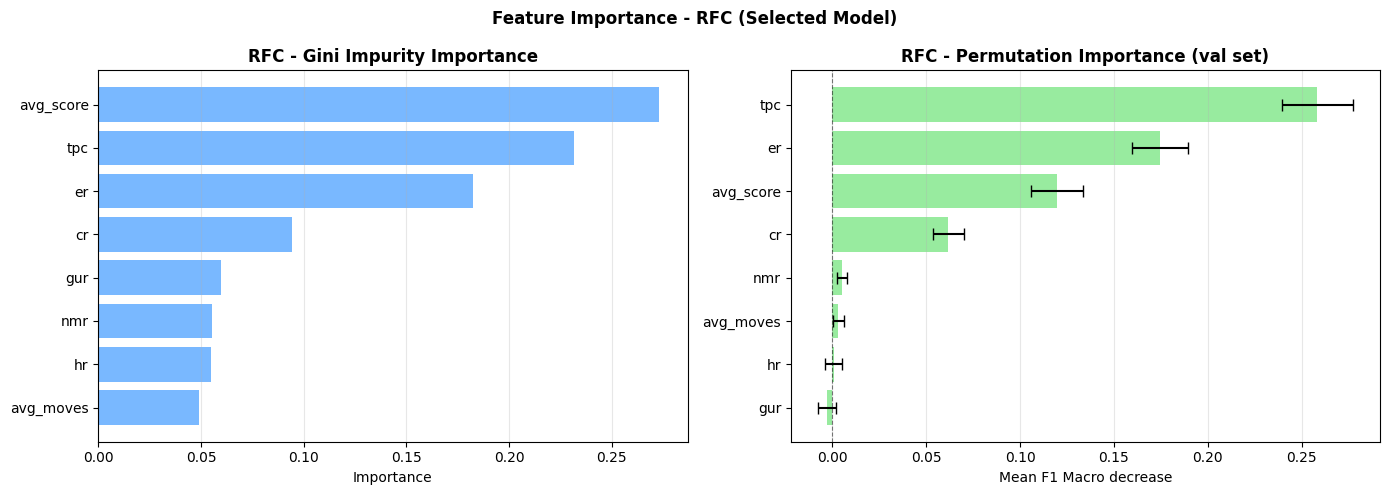

Permutation Importance Ranking (by F1 Macro decrease):
  tpc            :  0.2585 ± 0.0190
  er             :  0.1746 ± 0.0150
  avg_score      :  0.1197 ± 0.0139
  cr             :  0.0616 ± 0.0082
  nmr            :  0.0051 ± 0.0027
  avg_moves      :  0.0030 ± 0.0030
  hr             :  0.0007 ± 0.0045
  gur            : -0.0030 ± 0.0049


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Feature Importance - {best_name} (Selected Model)',
             fontsize=12, fontweight='bold')

# Left: model-native importance if available; otherwise permutation importance on train set
ax = axes[0]
if hasattr(best_model, 'feature_importances_'):
    imp = best_model.feature_importances_
    order = np.argsort(imp)
    bar_color = '#58A6FF' if best_name == 'RFC' else '#F44336'
    ax.barh([FEATURES[i] for i in order], imp[order],
            color=bar_color, alpha=0.8)
    label = 'Gini Impurity Importance' if best_name == 'RFC' else 'Built-in Importance'
    ax.set_title(f'{best_name} - {label}', fontweight='bold')
    ax.set_xlabel('Importance')
else:
    perm_train = permutation_importance(
        best_model, X_train_sc, y_train,
        n_repeats=30, random_state=42, n_jobs=-1,
        scoring='f1_macro')
    order = np.argsort(perm_train.importances_mean)
    ax.barh([FEATURES[i] for i in order],
            perm_train.importances_mean[order],
            xerr=perm_train.importances_std[order],
            color='#F44336', alpha=0.8, capsize=4)
    ax.axvline(0, color='black', lw=0.8, ls='--', alpha=0.5)
    ax.set_title(f'{best_name} - Permutation Importance (train set)', fontweight='bold')
    ax.set_xlabel('Mean F1 Macro decrease')

ax.grid(alpha=0.3, axis='x')

# Right: Permutation Importance (val set)
ax = axes[1]
perm = permutation_importance(
    best_model, X_val_sc, y_val,
    n_repeats=30, random_state=42, n_jobs=-1,
    scoring='f1_macro')
order = np.argsort(perm.importances_mean)
ax.barh([FEATURES[i] for i in order],
        perm.importances_mean[order],
        xerr=perm.importances_std[order],
        color='#7EE787', alpha=0.8, capsize=4)
ax.axvline(0, color='black', lw=0.8, ls='--', alpha=0.5)
ax.set_title(f'{best_name} - Permutation Importance (val set)', fontweight='bold')
ax.set_xlabel('Mean F1 Macro decrease')
ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print('Permutation Importance Ranking (by F1 Macro decrease):')
for i in np.argsort(perm.importances_mean)[::-1]:
    print(f'  {FEATURES[i]:<15}: {perm.importances_mean[i]:>7.4f} '
          f'± {perm.importances_std[i]:.4f}')


## 10. ***Save & Verify Model***

In [21]:
model_pkg = {
    'model'   : best_model,
    'scaler'  : scaler,
    'f1_score': float(f1_test),
}

folders = Path("Files")
folders.mkdir(parents=True, exist_ok=True)
path_folder = folders / "Difficulty_Recommender.pkl"

with open(path_folder, 'wb') as f:
    pickle.dump(model_pkg, f)

size_kb = Path(path_folder).stat().st_size / 1024
print(f'Saved to  : {path_folder}')
print(f'Model type: {type(best_model).__name__}  ({best_name})')
print(f'Test F1   : {f1_test:.4f}')
print(f'File size : {size_kb:.1f} KB')

Saved to  : Files\Difficulty_Recommender.pkl
Model type: RandomForestClassifier  (RFC)
Test F1   : 0.7127
File size : 11443.0 KB


In [22]:
# Verification
with open(path_folder, 'rb') as f:
    loaded = pickle.load(f)

m_loaded = loaded['model']
s_loaded = loaded['scaler']

personas = [
    ('Speedrunner',  [2.5,  0.02, 0.02, 0.98, 0.20, 0.05, 40.0, 900.0]),
    ('Average',      [9.0,  0.12, 0.15, 0.70, 0.45, 0.30, 28.0, 380.0]),
    ('Struggling',   [22.0, 0.42, 0.50, 0.30, 0.40, 0.75, 15.0,  60.0]),
]

print(f'{"Persona":<14} {"Pred Diff":<12} {"Confidence":>10}  Probas')
print('-' * 68)
for name, feat_vals in personas:
    sample    = np.array([feat_vals])
    sample_sc = s_loaded.transform(sample)
    pred      = m_loaded.predict(sample_sc)[0]
    proba     = m_loaded.predict_proba(sample_sc)[0]
    conf      = float(max(proba)) * 100
    p_str     = '  '.join(f'{CLASS_NAMES[i]}={proba[i]:.2f}' for i in range(3))
    print(f'{name:<14} {CLASS_NAMES[pred]:<12} {conf:>9.1f}%  {p_str}')

Persona        Pred Diff    Confidence  Probas
--------------------------------------------------------------------
Speedrunner    Hard              93.5%  Easy=0.01  Normal=0.06  Hard=0.94
Average        Normal            70.1%  Easy=0.23  Normal=0.70  Hard=0.07
Struggling     Easy              94.3%  Easy=0.94  Normal=0.05  Hard=0.01
